In [3]:
import os

import numpy as np
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator, LogFormatterMathtext
import pandas as pd

In [12]:
DATA_DIR = "./data/benchmarks/"
NUM_GAMES = 500
NUM_WARMUP_GAMES = 100
BATCH_SIZE = 1
NUM_BATCH_SIZES = 16
THREAD_NUMS = [1, 16, 32]

In [7]:
def get_path(num_threads, tensor_playouts=False):
    if tensor_playouts:
        return os.path.join("./data", f"ludii_speeds_tensor_playouts_{num_threads}_threads.csv")
    else:
        return os.path.join("./data", f"ludii_speeds_regular_playouts_{num_threads}_threads.csv")

ludii_caches_by_thread_num = {
    thread_num: pd.read_csv(get_path(thread_num, tensor_playouts=False))
    for thread_num in THREAD_NUMS
}

ludii_tensor_caches_by_thread_num = {
    thread_num: pd.read_csv(get_path(thread_num, tensor_playouts=True))
    for thread_num in THREAD_NUMS
}

In [8]:
def get_data_from_cache(game: str):
    cache_str = f"cache-{game}-{NUM_GAMES}-{NUM_WARMUP_GAMES}-{BATCH_SIZE}-{NUM_BATCH_SIZES}.npz"
    full_path = os.path.join(DATA_DIR, game, cache_str)
    cache = np.load(full_path, allow_pickle=True)

    batch_sizes = cache['batch_sizes']
    ludii_moves_per_second = cache['ludii_moves_per_second']
    ldx_times = cache['ldx_times']
    ldx_total_steps = cache['ldx_total_steps']
    pgx_times = cache.get('pgx_times')
    pgx_total_steps = cache.get('pgx_total_steps')

    average_ldx_moves_per_second = np.mean(ldx_total_steps / ldx_times, axis=1)
    std_ldx_moves_per_second = np.std(ldx_total_steps / ldx_times, axis=1)

    if pgx_times.any():
        average_pgx_moves_per_second = np.mean(pgx_total_steps / pgx_times, axis=1)
        std_pgx_moves_per_second = np.std(pgx_total_steps / pgx_times, axis=1)

    else:
        average_pgx_moves_per_second = None
        std_pgx_moves_per_second = None

    return batch_sizes, ludii_moves_per_second, average_ldx_moves_per_second, std_ldx_moves_per_second, average_pgx_moves_per_second, std_pgx_moves_per_second

In [30]:
def style_log_axes(ax, batch_sizes, left_factor=0.6, right_factor=1.5):
    max_bs = max(batch_sizes)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlim(left_factor, right_factor * max_bs)
    ax.set_ylim(1e3, 1e9)
    ax.xaxis.set_major_locator(LogLocator(base=2, subs=[1.0], numticks=len(batch_sizes)))
    ax.xaxis.set_major_formatter(LogFormatterMathtext(base=2))
    ax.xaxis.set_minor_locator(LogLocator(base=2, subs='auto', numticks=len(batch_sizes)*8))
    ax.xaxis.set_minor_formatter(LogFormatterMathtext(base=2))
    ax.grid(True, which='major', linestyle=':', linewidth=0.8, alpha=0.8)

    ax.tick_params(axis='both', labelsize=10)

eb_kwargs = {
    'linestyle':       '-',
    'linewidth':        1.5,
    'capsize':          4,
    'elinewidth':       1,
    'markeredgewidth':  1
}

# General configuration
mpl.rcParams.update({
    "text.usetex": False, 
    "font.family": "serif",     
    "font.size": 8,        
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "figure.titlesize": 14,
    "lines.linewidth": 1.2,
    "lines.markersize": 4,
    "axes.linewidth": 0.8,
    "legend.frameon": True,
    "legend.loc": "lower right",
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})

colors = ['#3599BF', '#CE6661', '#64B268', "#CFAA24", '#E68656']

In [20]:
ludii_caches_by_thread_num[1]

,Name,p/s,m/s,TotalPlayouts
0,Wolf and Sheep,9199.994660,817136.325707,276000
1,Havannah,2170.457742,261534.691271,65114
2,Hex,7580.445518,815179.692370,227414
3,Connect Four,27680.193660,589845.531572,830406
4,Connect6,356.766112,66331.432798,10704
5,Dai Hasami Shogi,359.388176,77503.850092,10782
6,Gomoku,7277.196112,818895.311514,218317
7,Pente,397.054719,61642.678489,11912
8,Tic-Tac-Toe,116846.358125,920886.299350,3505391
9,Yavalath,37978.748918,745480.751612,1139363



Game 'tic_tac_toe': 43.89× faster than Ludii (365814946.4488974 vs. 8335658.82 moves/sec)
Game 'tic_tac_toe': 0.83× faster than PGX (365814946.4488974 vs. 439506415.61 moves/sec)

Game 'connect_four': 24.39× faster than Ludii (160831587.74499714 vs. 6593055.44 moves/sec)
Game 'connect_four': 0.60× faster than PGX (160831587.74499714 vs. 268445565.82 moves/sec)

Game 'hex': 14.56× faster than Ludii (209350752.6134902 vs. 14381228.22 moves/sec)
Game 'hex': 1.59× faster than PGX (209350752.6134902 vs. 131715936.92 moves/sec)

Game 'reversi': 22.81× faster than Ludii (16677060.131909415 vs. 731242.69 moves/sec)
Game 'reversi': 0.33× faster than PGX (16677060.131909415 vs. 50150911.51 moves/sec)

Game 'gomoku': 9.99× faster than Ludii (75859327.92179833 vs. 7589741.56 moves/sec)

Game 'pente': 95.87× faster than Ludii (25391746.419132996 vs. 264869.66 moves/sec)

Game 'yavalath': 27.28× faster than Ludii (159448575.80807525 vs. 5844978.79 moves/sec)

Game 'dai_hasami_shogi': 12.43× faster 

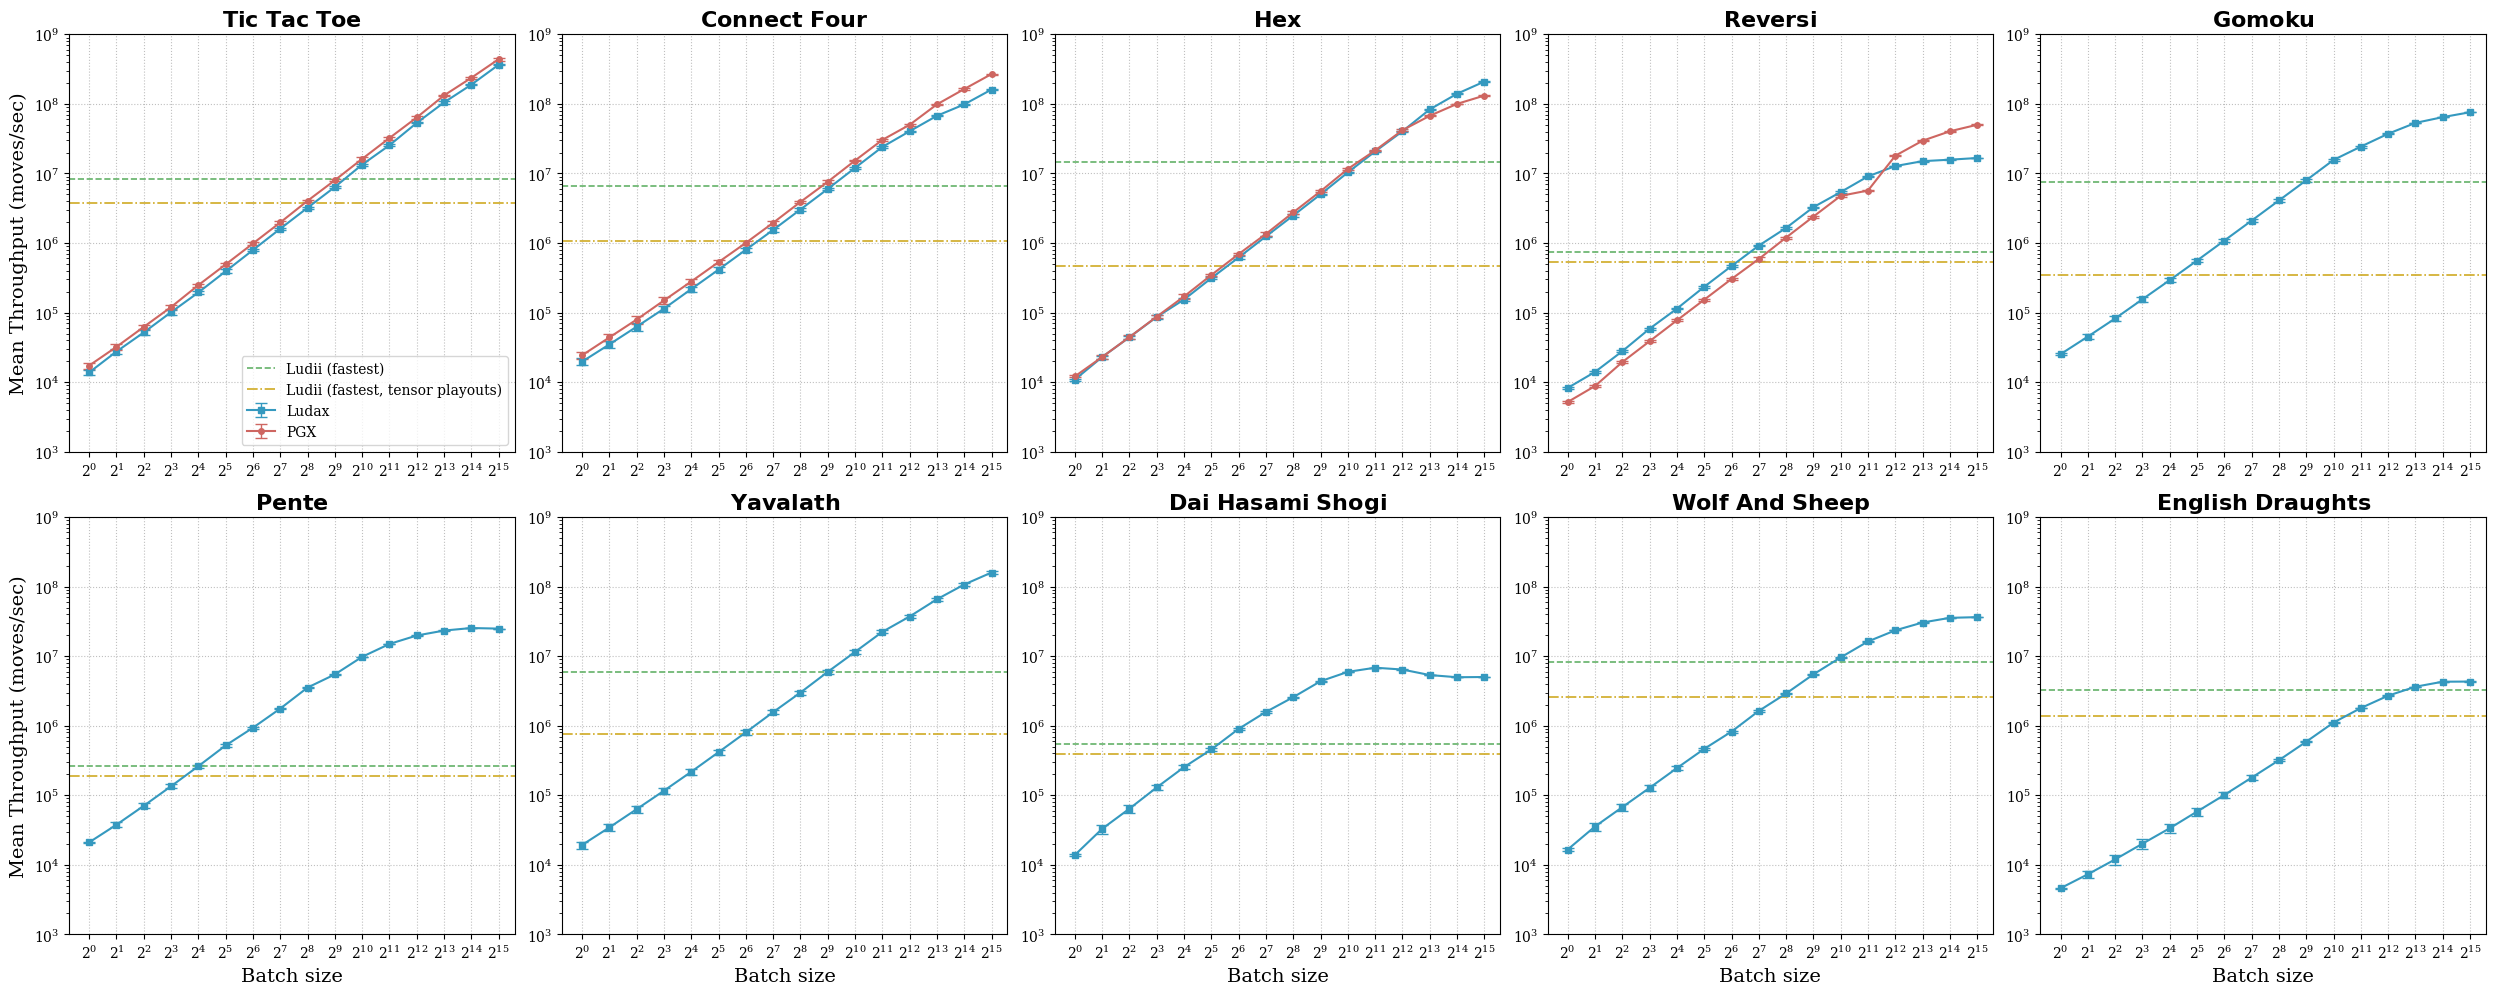

In [ ]:
GAMES = [
    ["tic_tac_toe", "connect_four", "hex", "reversi", "gomoku"],
    ["pente", "yavalath", "dai_hasami_shogi", "wolf_and_sheep", "english_draughts"]
]

def format_game_name(game_name):
    if game_name == "tic_tac_toe":
        return "Tic-Tac-Toe"
    return game_name.replace('_', ' ').title().replace("And", "and")

fig, axs = plt.subplots(len(GAMES), len(GAMES[0]), figsize=(5 * len(GAMES[0]), 5 * len(GAMES)))

for i, row in enumerate(GAMES):
    for j, game in enumerate(row):
        ax = axs[i][j]

        batch_sizes, ludii_moves_per_second, average_ldx_moves_per_second, std_ldx_moves_per_second, average_pgx_moves_per_second, std_pgx_moves_per_second = get_data_from_cache(game)

        ax.errorbar(batch_sizes, average_ldx_moves_per_second, yerr=std_ldx_moves_per_second, marker='s', color=colors[0], label='Ludax', **eb_kwargs)
        if average_pgx_moves_per_second is not None:
            ax.errorbar(batch_sizes, average_pgx_moves_per_second, yerr=std_pgx_moves_per_second, marker='o', color=colors[1], label='PGX', **eb_kwargs)

        formatted = format_game_name(game)
        ludii_speeds = [
            ludii_caches_by_thread_num[thread_num].loc[ludii_caches_by_thread_num[thread_num]['Name'] == formatted, 'm/s'].values[0]
            for thread_num in THREAD_NUMS
        ]

        ludii_tensor_speeds = [
            ludii_tensor_caches_by_thread_num[thread_num].loc[ludii_tensor_caches_by_thread_num[thread_num]['Name'] == formatted, 'm/s'].values[0]
            for thread_num in THREAD_NUMS
        ]

        fastest_ludii_speed = max(ludii_speeds)
        fastest_ludii_tensor_speed = max(ludii_tensor_speeds)
        ax.axhline(y=fastest_ludii_speed, linestyle='--', label=f'Ludii (fastest)', color=colors[2], alpha=1)
        ax.axhline(y=fastest_ludii_tensor_speed, linestyle='-.', label=f'Ludii (fastest, tensor playouts)', color=colors[3], alpha=1)

        # line_styles = [':', '--', '-.']
        # for k, num_threads in enumerate(THREAD_NUMS):
        #     ludii_ms = ludii_moves_per_second[k]
        #     ax.axhline(y=ludii_ms, linestyle=line_styles[k], label=f'Ludii ({num_threads} threads)', color=colors[2], alpha=1)

        style_log_axes(ax, batch_sizes)

        if i == 1:
            ax.set_xlabel('Batch size')

        if j == 0:
            ax.set_ylabel('Mean Throughput (moves/sec)')

        formatted_title = "{" + game.title().replace('_', '\\text{ }') + "}"
        ax.set_title(f"$\\bf{formatted_title}$")

        if i == 0 and j == 0:
            ax.legend()

        fastest_ludii_speed = max(ludii_moves_per_second)
        fastest_ldx_speed = max(average_ldx_moves_per_second)
        print(f"\nGame '{game}': {fastest_ldx_speed / fastest_ludii_speed:.2f}× faster than Ludii ({fastest_ldx_speed} vs. {fastest_ludii_speed:.2f} moves/sec)")
        print(f"Game '{game}': {fastest_ldx_speed / fastest_ludii_tensor_speed:.2f}× faster than Ludii with tensor playouts ({fastest_ldx_speed:.2f} vs. {fastest_ludii_tensor_speed:.2f} moves/sec)")

        if average_pgx_moves_per_second is not None:
            fastest_pgx_speed = max(average_pgx_moves_per_second)
            print(f"Game '{game}': {fastest_ldx_speed / fastest_pgx_speed:.2f}× faster than PGX ({fastest_ldx_speed} vs. {fastest_pgx_speed:.2f} moves/sec)")

handles, labels = axs[0][0].get_legend_handles_labels()
fig.tight_layout()
fig.savefig("./throughput_comparison.pdf")